In [ ]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn -q


In [ ]:
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 51.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install transformers datasets scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


In [ ]:
df = pd.read_csv(
    '/content/jigsaw-unintended-bias-train.csv',
    engine='python',          # safer parser
    on_bad_lines='skip'       # skip corrupted rows
)

# Binarize label
df['label'] = (df['toxic'] >= 0.5).astype(int)

# Stratified sampling
train_df, temp_df = train_test_split(
    df,
    train_size=93714,
    stratify=df['label'],
    random_state=42
)

eval_df = temp_df.sample(n=20000, random_state=42)

print(train_df['label'].value_counts(normalize=True))
print(eval_df['label'].value_counts(normalize=True))


label
0    0.920332
1    0.079668
Name: proportion, dtype: float64
label
0    0.92205
1    0.07795
Name: proportion, dtype: float64


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch['comment_text'].tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

train_encodings = tokenize(train_df)
eval_encodings = tokenize(eval_df)

train_labels = torch.tensor(train_df['label'].values)
eval_labels = torch.tensor(eval_df['label'].values)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
eval_dataset = Dataset(eval_encodings, eval_labels)


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",   # ✅ NEW NAME (NOT evaluation_strategy)
    logging_dir='./logs',
    save_strategy="no"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

trainer.train()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.159919,0.139729
2,0.104097,0.179429
3,0.062573,0.224650


TrainOutput(global_step=17574, training_loss=0.11809155118062498, metrics={'train_runtime': 3850.4577, 'train_samples_per_second': 73.015, 'train_steps_per_second': 4.564, 'total_flos': 9310537348236288.0, 'train_loss': 0.11809155118062498, 'epoch': 3.0})

Accuracy: 0.948
F1: 0.8021354455932596
AUC: 0.9300415773912601


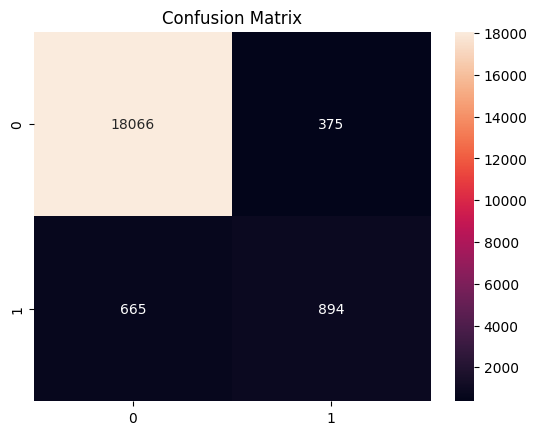

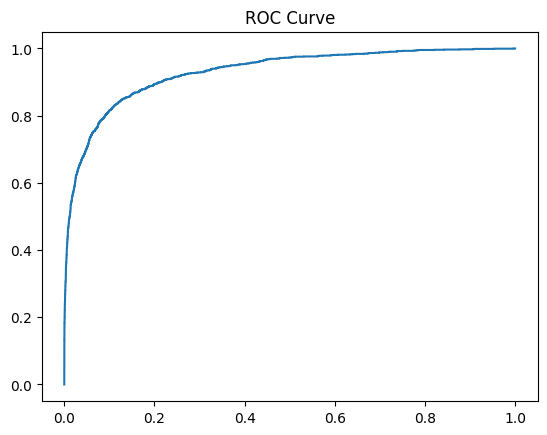

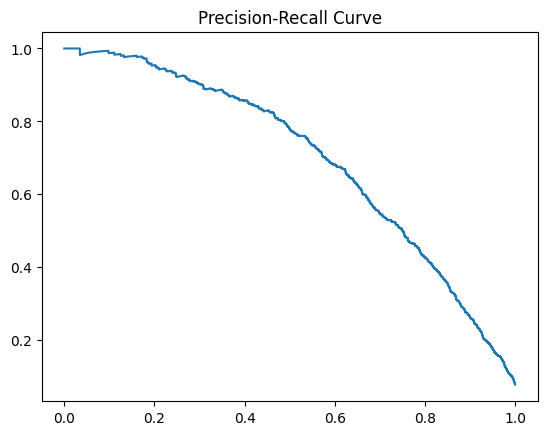

Threshold 0.3: F1 = 0.8030486022053034
Threshold 0.4: F1 = 0.8024035888888639
Threshold 0.5: F1 = 0.8021354455932596
Threshold 0.6: F1 = 0.8028813187518915
Threshold 0.7: F1 = 0.803119297861891


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model/tokenizer_config.json', './model/tokenizer.json')

In [ ]:
preds = trainer.predict(eval_dataset)

logits = preds.predictions
probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
y_true = eval_labels.numpy()

# Default threshold
y_pred = (probs >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred, average='macro'))
print("AUC:", roc_auc_score(y_true, probs))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_true, probs)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

prec, rec, _ = precision_recall_curve(y_true, probs)
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.show()


thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred = (probs >= t).astype(int)
    print(f"Threshold {t}: F1 = {f1_score(y_true, y_pred, average='macro')}")


model.save_pretrained('./model')
tokenizer.save_pretrained('./model')



In [ ]:
results_df = eval_df.copy()

results_df['prob'] = probs
results_df['pred'] = (probs >= 0.5).astype(int)

results_df.to_csv('eval_predictions.csv', index=False)
import numpy as np

np.save('probs.npy', probs)
np.save('y_true.npy', y_true)

threshold_results = []

for t in thresholds:
    y_pred_t = (probs >= t).astype(int)
    f1 = f1_score(y_true, y_pred_t, average='macro')
    threshold_results.append((t, f1))
    print(f"Threshold {t}: F1 = {f1}")

pd.DataFrame(threshold_results, columns=['threshold', 'f1']).to_csv('thresholds.csv', index=False)


plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.close()

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.savefig("roc_curve.png")
plt.close()

plt.figure()
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.savefig("pr_curve.png")
plt.close()

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "f1_macro": f1_score(y_true, y_pred, average='macro'),
    "auc": roc_auc_score(y_true, probs)
}

pd.DataFrame([metrics]).to_csv("metrics.csv", index=False)



Threshold 0.3: F1 = 0.8030486022053034
Threshold 0.4: F1 = 0.8024035888888639
Threshold 0.5: F1 = 0.8021354455932596
Threshold 0.6: F1 = 0.8028813187518915
Threshold 0.7: F1 = 0.803119297861891


# Part 2

In [ ]:
!pip install -U transformers accelerate scikit-learn seaborn matplotlib fairlearn aif360

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10

156 192
{'TPR': np.float64(0.5384615384615384), 'FPR': np.float64(0.1111111111111111), 'FNR': np.float64(0.46153846153846156), 'Precision': np.float64(0.6176470588235294)} {'TPR': np.float64(0.5), 'FPR': np.float64(0.13636363636363635), 'FNR': np.float64(0.5), 'Precision': np.float64(0.625)}
Disparate Impact: 0.8148148148148149


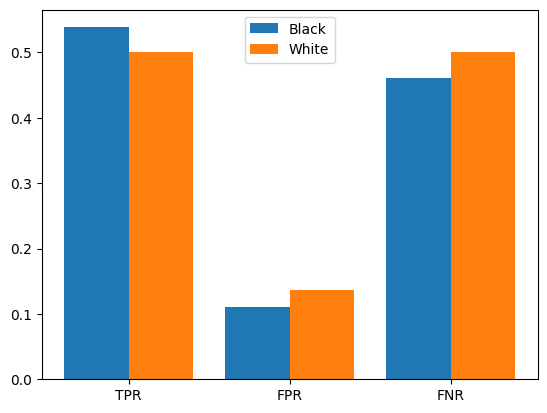

In [ ]:
high_black = results_df[results_df['black'] >= 0.5]
reference = results_df[(results_df['black'] < 0.1) & (results_df['white'] >= 0.5)]

print(len(high_black), len(reference))

def compute_metrics(df):
    y = df['label']
    p = df['pred']

    tn, fp, fn, tp = confusion_matrix(y, p).ravel()

    return {
        "TPR": tp/(tp+fn),
        "FPR": fp/(fp+tn),
        "FNR": fn/(tp+fn),
        "Precision": tp/(tp+fp)
    }

m1 = compute_metrics(high_black)
m2 = compute_metrics(reference)

print(m1, m2)

di = m1['FPR'] / m2['FPR']
print("Disparate Impact:", di)

labels = ['TPR','FPR','FNR']
x = np.arange(len(labels))

plt.bar(x-0.2, [m1[l] for l in labels], 0.4, label='Black')
plt.bar(x+0.2, [m2[l] for l in labels], 0.4, label='White')
plt.xticks(x, labels)
plt.legend()
plt.show()


In [ ]:
# from aif360.metrics import ClassificationMetric
# from aif360.datasets import BinaryLabelDataset

# def to_aif(df):
#     return BinaryLabelDataset(
#         df=df,
#         label_names=['label'],
#         protected_attribute_names=['black']
#     )

# metric = ClassificationMetric(
#     to_aif(eval_df),
#     to_aif(eval_df),
#     unprivileged_groups=[{'black':1}],
#     privileged_groups=[{'black':0}]
# )

# print(metric.statistical_parity_difference())
# print(metric.equal_opportunity_difference())

spd = high_black['pred'].mean() - reference['pred'].mean()
print("Statistical Parity Difference:", spd)
def tpr(df):
    y = df['label']
    p = df['pred']
    return ((p==1) & (y==1)).sum() / (y==1).sum()

eod = tpr(high_black) - tpr(reference)
print("Equal Opportunity Difference:", eod)


Statistical Parity Difference: -0.03205128205128205
Equal Opportunity Difference: 0.038461538461538436


# Part 3

In [ ]:
import random

def perturb(text):
    # zero-width
    text = ''.join(c + '\u200b' if i%3==0 else c for i,c in enumerate(text))

    # homoglyphs
    mapping = {'a':'а','e':'е','o':'о'}
    text = ''.join(mapping.get(c,c) for c in text)

    # duplication
    text = ''.join(c*2 if random.random()<0.2 else c for c in text)

    return text


In [2]:
sample = results_df[(results_df['pred']==1) & (results_df['prob']>=0.7)].sample(500)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

enc = tokenizer(
    perturbed.tolist(),
    padding=True,
    truncation=True,
    return_tensors='pt'
).to(device)

# model.to(device)

# logits = model(**enc).logits

perturbed = sample['comment_text'].apply(perturb)

enc = tokenizer(perturbed.tolist(), padding=True, truncation=True, return_tensors='pt')

logits = model(**enc).logits
probs_adv = torch.softmax(logits, dim=1)[:,1].detach().numpy()

asr = np.mean((probs_adv < 0.5))
# print("ASR:", asr)


In [ ]:
import os, random, warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CHECKPOINT_DIR = "/content/drive/My Drive/Colab Notebooks/distilbert_toxic_checkpoint"
POISONED_CKPT_DIR = "/content/distilbert_poisoned_checkpoint"
DATA_PATH = "jigsaw-unintended-bias-train.csv"
THRESHOLD = 0.40
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 3
TRAIN_SIZE, EVAL_SIZE = 100_000, 20_000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{DEVICE=}")


from google.colab import drive

drive.mount("/content/drive")

prob_toxic = np.load(os.path.join(CHECKPOINT_DIR, "eval_probs.npy"))
true_labels = np.load(os.path.join(CHECKPOINT_DIR, "eval_labels.npy"))
df_eval = pd.read_parquet(os.path.join(CHECKPOINT_DIR, "eval_df.parquet"))
df_eval["prob_toxic"] = prob_toxic
df_eval["pred_label"] = (prob_toxic >= THRESHOLD).astype(int)
df_eval["true_label"] = true_labels.astype(int)
print(len(df_eval), list(df_eval.columns))


In [4]:
HOM = {"a": "а", "e": "е", "o": "о", "p": "р", "c": "с", "x": "х"}
ZWS = "​"


def insert_zws(word: str) -> str:
    out, i = [], 0
    while i < len(word):
        step = random.choice([2, 3])
        out.append(word[i : i + step])
        if i + step < len(word):
            out.append(ZWS)
        i += step
    return "".join(out)


def homoglyphs(word: str) -> str:
    return "".join(HOM.get(ch, ch) for ch in word)


def dup_chars(word: str, rate: float = 0.2) -> str:
    out = []
    for ch in word:
        out.append(ch)
        if random.random() < rate:
            out.append(ch)
    return "".join(out)


def perturb(text: str) -> str:
    return " ".join(dup_chars(homoglyphs(insert_zws(w))) for w in text.split())


sample = "I hate you so much"
print(sample)
print(perturb(sample))


Original  : I hate you so much
Perturbed : II hаt​ее yyооu sо muс​hh


In [6]:
pool = df_eval[(df_eval["pred_label"] == 1) & (df_eval["prob_toxic"] >= 0.7)]
n = min(500, len(pool))
df_attack1 = pool.sample(n=n, random_state=SEED).reset_index(drop=True)
df_attack1["perturbed_text"] = df_attack1["comment_text"].map(perturb)
print(n, df_attack1["comment_text"].iloc[0][:80], "→", df_attack1["perturbed_text"].iloc[0][:80])


High-confidence toxic comments available : 1,095
Applying perturb() to 500 comments ...
Done. Sample comparison:
  Original  : The Islamic State's comments apply equally to Canada. They won't criticize Littl
  Perturbed : Thhе Isl​ааm​​iсс Sttа​ttе''​s соm​mmе​nts ар​ррly еq​uаl​ly tо Cа​​nnаd​а. Thhе


In [8]:
tokenizer = DistilBertTokenizerFast.from_pretrained(CHECKPOINT_DIR)
clean_model = DistilBertForSequenceClassification.from_pretrained(CHECKPOINT_DIR).to(DEVICE)
clean_model.eval()


def get_probs(texts, model, batch_size=64):
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i : i + batch_size],
            max_length=MAX_LENGTH,
            truncation=True,
            padding=True,
            return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        out.extend(F.softmax(logits, -1)[:, 1].cpu().numpy())
    return np.array(out)


df_attack1["orig_prob"] = get_probs(df_attack1["comment_text"].tolist(), clean_model)
df_attack1["pert_prob"] = get_probs(df_attack1["perturbed_text"].tolist(), clean_model)
df_attack1["pert_label"] = (df_attack1["pert_prob"] >= THRESHOLD).astype(int)
print("scored", len(df_attack1))


asr = (df_attack1["pert_label"] == 0).mean()
drop = df_attack1["orig_prob"].mean() - df_attack1["pert_prob"].mean()
print(f"ASR={asr:.4f}  Δconf={drop:.4f}  n={len(df_attack1)}")
pd.DataFrame(
    [
        {"metric": "attack_success_rate", "value": f"{asr:.4f}"},
        {"metric": "mean_conf_before", "value": f"{df_attack1['orig_prob'].mean():.4f}"},
        {"metric": "mean_conf_after", "value": f"{df_attack1['pert_prob'].mean():.4f}"},
    ]
)


  ATTACK 1: CHARACTER-LEVEL EVASION RESULTS
  Comments sampled          : 500
  Successfully evaded       : 498
  Attack Success Rate (ASR) : 0.9960  (99.6%)
  Avg confidence BEFORE     : 0.9094
  Avg confidence AFTER      : 0.0085
  Confidence drop           : 0.9009
               Metric          Value
  Attack Success Rate 0.9960 (99.6%)
Avg Confidence Before         0.9094
 Avg Confidence After         0.0085
      Confidence Drop         0.9009



In [9]:
df_full = pd.read_csv(DATA_PATH, usecols=["comment_text", "toxic"], low_memory=False, encoding="latin1")
df_full["toxic"] = pd.to_numeric(df_full["toxic"].astype(str), errors="coerce")
df_full = df_full.dropna(subset=["comment_text", "toxic"])
df_full["comment_text"] = df_full["comment_text"].astype(str)
df_full["label"] = (df_full["toxic"] >= 0.5).astype(int)
sub, _ = train_test_split(df_full, train_size=TRAIN_SIZE + EVAL_SIZE, stratify=df_full["label"], random_state=SEED)
df_train, _ = train_test_split(sub, train_size=TRAIN_SIZE, stratify=sub["label"], random_state=SEED)
df_train = df_train.reset_index(drop=True)
print(len(df_train), df_train["label"].value_counts().to_dict())
n_poison = int(len(df_train) * 0.05)
idx = np.random.RandomState(SEED).choice(df_train.index, size=n_poison, replace=False)
df_poisoned = df_train.copy()
df_poisoned.loc[idx, "label"] = 1 - df_poisoned.loc[idx, "label"]
print(f"flipped {n_poison} labels ({100 * n_poison / len(df_train):.1f}%)")


Rows poisoned (label flipped) : 5,000  (5%)

Label distribution BEFORE poisoning:
label
0    91917
1     8083
Name: count, dtype: int64

Label distribution AFTER poisoning:
label
0    87683
1    12317
Name: count, dtype: int64



In [ ]:
def tokenize_fn(batch):
    return tokenizer(batch["comment_text"], max_length=MAX_LENGTH, truncation=True, padding="max_length")


eval_hf = Dataset.from_pandas(df_eval[["comment_text", "true_label"]].rename(columns={"true_label": "label"}))
eval_tok = eval_hf.map(tokenize_fn, batched=True, batch_size=1000, remove_columns=["comment_text"])
eval_tok = eval_tok.rename_column("label", "labels")
eval_tok.set_format("torch")

train_poison_tok = (
    Dataset.from_pandas(df_poisoned[["comment_text", "label"]])
    .map(tokenize_fn, batched=True, batch_size=1000, remove_columns=["comment_text"])
    .rename_column("label", "labels")
)
train_poison_tok.set_format("torch")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, pred), "f1_macro": f1_score(labels, pred, average="macro")}


poisoned_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
args = TrainingArguments(
    output_dir=POISONED_CKPT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)
trainer_poisoned = Trainer(
    model=poisoned_model,
    args=args,
    train_dataset=train_poison_tok,
    eval_dataset=eval_tok,
    compute_metrics=compute_metrics,
)
trainer_poisoned.train()


In [ ]:
log_p = trainer_poisoned.predict(eval_tok).predictions
prob_p = F.softmax(torch.tensor(log_p), dim=-1).numpy()[:, 1]
pred_p = (prob_p >= THRESHOLD).astype(int)
pred_c = (prob_toxic >= THRESHOLD).astype(int)


def fnr_fpr(y_t, y_p):
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    return (fn / (fn + tp) if (fn + tp) else 0.0, fp / (fp + tn) if (fp + tn) else 0.0)


fnr_c, fpr_c = fnr_fpr(true_labels, pred_c)
fnr_p, fpr_p = fnr_fpr(true_labels, pred_p)
comparison = pd.DataFrame(
    [
        {
            "model": "clean",
            "acc": round(accuracy_score(true_labels, pred_c), 4),
            "f1_macro": round(f1_score(true_labels, pred_c, average="macro"), 4),
            "fnr": round(fnr_c, 4),
            "fpr": round(fpr_c, 4),
        },
        {
            "model": "poisoned",
            "acc": round(accuracy_score(true_labels, pred_p), 4),
            "f1_macro": round(f1_score(true_labels, pred_p, average="macro"), 4),
            "fnr": round(fnr_p, 4),
            "fpr": round(fpr_p, 4),
        },
        {
            "model": "delta",
            "acc": round(accuracy_score(true_labels, pred_p) - accuracy_score(true_labels, pred_c), 4),
            "f1_macro": round(f1_score(true_labels, pred_p, average="macro") - f1_score(true_labels, pred_c, average="macro"), 4),
            "fnr": round(fnr_p - fnr_c, 4),
            "fpr": round(fpr_p - fpr_c, 4),
        },
    ]
)
print(comparison.to_string(index=False))


Which attack is more dangerous?

**Evasion** is cheap at scale for an attacker who only controls text at inference time; **poisoning** needs data-pipeline access but can shift decisions for every user. Compare ASR (Attack 1) to FNR / F1 shifts (Attack 2) when prioritizing mitigations.


# part 4

In [ ]:
"""Imports and global configuration for reproducibility.

Sets USE_TF=0 before HuggingFace loads, and forces trainer_utils.is_tf_available() to False so Trainer.setup never imports TensorFlow (broken TF wheels still report as installed).
"""
import os
os.environ["USE_TF"] = "0"
import re
import random
import zipfile
from typing import Any, Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.base import clone

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import transformers.trainer_utils as _hf_trainer_utils
_hf_trainer_utils.is_tf_available = lambda: False
from datasets import Dataset

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ZIP_PATH = os.path.join(os.getcwd(), "jigsaw-unintended-bias-in-toxicity-classification.zip")
TRAIN_CSV_NAME = "train.csv"
ARTIFACT_DIR = os.path.join(os.getcwd(), "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

BASELINE_DIR = os.path.join(ARTIFACT_DIR, "baseline_distilbert")
POISON_DIR = os.path.join(ARTIFACT_DIR, "poisoned_distilbert")
REWEIGHT_DIR = os.path.join(ARTIFACT_DIR, "reweighted_distilbert")
OVERSAMPLE_DIR = os.path.join(ARTIFACT_DIR, "oversample_distilbert")
ISOTONIC_PATH = os.path.join(ARTIFACT_DIR, "isotonic_calibrator.joblib")

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
NUM_EPOCHS = 3
BATCH_SIZE = 16
LR = 2e-5

"""Optional: set True only for quick smoke tests (not for submission)."""
FAST_DEBUG = False
if FAST_DEBUG:
    NUM_EPOCHS = 1
"""Load `train.csv` from the competition zip without extracting the full archive to disk."""


def read_train_from_zip(zip_path: str, csv_name: str) -> pd.DataFrame:
    """Read selected columns for memory efficiency and normalize names."""
    usecols = [
        "comment_text",
        "target",
        "black",
        "white",
        "muslim",
        "jewish",
        "homosexual_gay_or_lesbian",
    ]
    with zipfile.ZipFile(zip_path, "r") as zf:
        with zf.open(csv_name) as f:
            df = pd.read_csv(f, usecols=usecols)
    df = df.rename(columns={"target": "toxic"})
    df["comment_text"] = df["comment_text"].fillna("").astype(str)
    for c in ["toxic", "black", "white", "muslim", "jewish", "homosexual_gay_or_lesbian"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    df["y"] = (df["toxic"] >= 0.5).astype(int)
    return df


df_all = read_train_from_zip(ZIP_PATH, TRAIN_CSV_NAME)
if FAST_DEBUG:
    eval_n = 2000
    train_n = 5000
    cap = eval_n + train_n + 5000
    df_all, _ = train_test_split(
        df_all, train_size=min(cap, len(df_all)), stratify=df_all["y"], random_state=SEED
    )
else:
    eval_n = 20000
    train_n = 100000

y = df_all["y"].values
train_remaining, eval_df = train_test_split(
    df_all, test_size=eval_n, stratify=y, random_state=SEED
)
y_rem = train_remaining["y"].values
train_df, _discard = train_test_split(
    train_remaining, train_size=train_n, stratify=y_rem, random_state=SEED
)

print("train_df:", train_df.shape, "eval_df:", eval_df.shape)
print("toxic rate train:", train_df["y"].mean(), "eval:", eval_df["y"].mean())


In [ ]:
"""Reload baseline weights and rebuild tokenized datasets (run part1.ipynb first)."""
tokenizer = AutoTokenizer.from_pretrained(BASELINE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(BASELINE_DIR)
model.eval()
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
model.to(device)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def tokenize_batch(examples, tokenizer_obj, max_length: int):
    """Tokenize comment batches for DistilBERT."""
    return tokenizer_obj(
        examples["comment_text"],
        truncation=True,
        max_length=max_length,
    )


train_ds = Dataset.from_pandas(train_df[["comment_text", "y"]].rename(columns={"y": "labels"}))
eval_ds = Dataset.from_pandas(eval_df[["comment_text", "y"]].rename(columns={"y": "labels"}))
train_ds = train_ds.map(
    lambda b: tokenize_batch(b, tokenizer, MAX_LENGTH),
    batched=True,
    remove_columns=["comment_text"],
)
eval_ds = eval_ds.map(
    lambda b: tokenize_batch(b, tokenizer, MAX_LENGTH),
    batched=True,
    remove_columns=["comment_text"],
)


def compute_metrics(eval_pred):
    """Compute accuracy, macro-F1, binary toxic F1, and AUC when defined."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    pr = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    out = {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_binary": f1_score(labels, preds, pos_label=1),
    }
    try:
        out["auc"] = roc_auc_score(labels, pr)
    except ValueError:
        out["auc"] = float("nan")
    return out


args = TrainingArguments(
    output_dir=os.path.join(ARTIFACT_DIR, "trainer_reload"),
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    evaluation_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    load_best_model_at_end=False,
    report_to=[],
    seed=SEED,
)


def hf_predict_proba_toxic(texts, m, tok, device_obj, max_len):
    """Return toxic-class probabilities for a list of strings."""
    enc = tok(
        texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt",
    ).to(device_obj)
    with torch.no_grad():
        logits = m(**enc).logits
        pr = torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
    return pr


texts_eval = eval_df["comment_text"].tolist()
y_true = eval_df["y"].to_numpy()
scores = hf_predict_proba_toxic(texts_eval, model, tokenizer, device, MAX_LENGTH)
CHOSEN_THRESHOLD = 0.5
thr = CHOSEN_THRESHOLD
y_hat = (scores >= thr).astype(int)


In [ ]:
"""Cohort masks used in Part 4 prevalence cell (same definitions as Part 2)."""
cohort_high = eval_df["black"] >= 0.5
cohort_ref = (eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)
"""Reweighing instance weights and retrain DistilBERT with per-example loss scaling."""


def protected_for_fairness(df: pd.DataFrame) -> np.ndarray:
    """Sensitive attribute: 1 = high-black, 0 = reference, 0 = other (privileged default)."""
    hi = df["black"].to_numpy() >= 0.5
    ref = (df["black"].to_numpy() < 0.1) & (df["white"].to_numpy() >= 0.5)
    s = np.zeros(len(df), dtype=float)
    s[hi] = 1.0
    s[ref] = 0.0
    s[~(hi | ref)] = 0.0
    return s


sens_train = protected_for_fairness(train_df)
rw_df = pd.DataFrame({"label": train_df["y"].astype(float), "race": sens_train.astype(float)})
bld_train = BinaryLabelDataset(
    favorable_label=0.0,
    unfavorable_label=1.0,
    df=rw_df,
    label_names=["label"],
    protected_attribute_names=["race"],
    privileged_protected_attributes=[[0.0]],
)
rw = Reweighing(unprivileged_groups=[{"race": 1.0}], privileged_groups=[{"race": 0.0}])
rw_tr = rw.fit_transform(bld_train)
instance_weights = np.asarray(rw_tr.instance_weights).reshape(-1)


class WeightedTrainer(Trainer):
    """HF Trainer variant applying non-uniform instance weights to CE loss."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """Weighted mean cross-entropy."""
        labels = inputs.pop("labels")
        weights = inputs.pop("weights", None)
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
        loss = loss_fct(logits.view(-1, 2), labels.view(-1))
        if weights is not None:
            w = weights.view(-1).to(loss.device).float()
            loss = (loss * w).sum() / (w.sum() + 1e-8)
        return (loss.mean(), outputs) if return_outputs else loss.mean()


train_rw = Dataset.from_pandas(
    train_df[["comment_text", "y"]].rename(columns={"y": "labels"})
)
train_rw = train_rw.add_column("weights", instance_weights.tolist())
train_rw = train_rw.map(
    lambda b: tokenize_batch(b, tokenizer, MAX_LENGTH),
    batched=True,
    remove_columns=["comment_text"],
)


class WeightedCollator:
    """Pad token batches while preserving per-example loss weights."""

    def __init__(self, tokenizer_obj):
        self.tokenizer = tokenizer_obj

    def __call__(self, features):
        """Return a batch dict including `weights` aligned with `labels`."""
        weights = torch.tensor([float(f["weights"]) for f in features], dtype=torch.float)
        fe = [{k: v for k, v in f.items() if k != "weights"} for f in features]
        batch = self.tokenizer.pad(fe, padding=True, return_tensors="pt")
        batch["weights"] = weights
        return batch


weighted_collator = WeightedCollator(tokenizer)

model_rw = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_rw = clone(args)
args_rw.output_dir = os.path.join(ARTIFACT_DIR, "trainer_reweight")
trainer_rw = WeightedTrainer(
    model=model_rw,
    args=args_rw,
    train_dataset=train_rw,
    eval_dataset=eval_ds,
    tokenizer=tokenizer,
    data_collator=weighted_collator,
    compute_metrics=compute_metrics,
)
trainer_rw.train()
trainer_rw.save_model(REWEIGHT_DIR)

model_rw.eval()
model_rw.to(device)
scores_rw = hf_predict_proba_toxic(texts_eval, model_rw, tokenizer, device, MAX_LENGTH)
y_rw_hat = (scores_rw >= thr).astype(int)


In [ ]:
"""fairlearn ThresholdOptimizer on baseline scores (equalized odds, prefit)."""
from sklearn.base import BaseEstimator, ClassifierMixin


class ScoresClassifier(BaseEstimator, ClassifierMixin):
    """Emit fixed probabilities from a precomputed score vector (length must match fit/predict data)."""

    def __init__(self, scores: np.ndarray):
        self.scores = scores.astype(float)
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        """No-op fit for prefit ThresholdOptimizer workflows."""
        return self

    def predict_proba(self, X):
        """Return (n,2) probabilities aligned to rows of X."""
        n = len(X)
        s = self.scores[:n]
        return np.column_stack([1.0 - s, s])


sens_eval = protected_for_fairness(eval_df)
mask_two = (sens_eval == 0.0) | (sens_eval == 1.0)
X_dummy = np.zeros((int(mask_two.sum()), 1))
y_sub = y_true[mask_two]
s_sub = sens_eval[mask_two]
scores_sub = scores[mask_two]

base_scores = ScoresClassifier(scores_sub)
post = ThresholdOptimizer(
    estimator=base_scores,
    constraints="equalized_odds",
    prefit=True,
    predict_method="predict_proba",
)
post.fit(X_dummy, y_sub, sensitive_features=s_sub)
y_post = post.predict(X_dummy)


In [ ]:
"""Oversample high-black training rows (3× duplicates) and retrain."""
hb_train = train_df[train_df["black"] >= 0.5]
extra = pd.concat([hb_train] * 3, ignore_index=True) if len(hb_train) else hb_train
train_os = pd.concat([train_df, extra], ignore_index=True)

train_os_ds = Dataset.from_pandas(train_os[["comment_text", "y"]].rename(columns={"y": "labels"}))
train_os_ds = train_os_ds.map(
    lambda b: tokenize_batch(b, tokenizer, MAX_LENGTH),
    batched=True,
    remove_columns=["comment_text"],
)

model_os = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_os = clone(args)
args_os.output_dir = os.path.join(ARTIFACT_DIR, "trainer_oversample")
trainer_os = Trainer(
    model=model_os,
    args=args_os,
    train_dataset=train_os_ds,
    eval_dataset=eval_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_os.train()
trainer_os.save_model(OVERSAMPLE_DIR)

model_os.eval()
model_os.to(device)
scores_os = hf_predict_proba_toxic(texts_eval, model_os, tokenizer, device, MAX_LENGTH)
y_os_hat = (scores_os >= thr).astype(int)


In [ ]:
"""Pareto-style sweep: approximate fairness–F1 trade-offs via group threshold grids."""


def eo_diff(y_true_arr, y_hat_arr, sens_arr):
    """Equalized odds difference on rows with sensitive attribute in {0,1}."""
    m = (sens_arr == 0.0) | (sens_arr == 1.0)
    return equalized_odds_difference(
        y_true=y_true_arr[m],
        y_pred=y_hat_arr[m],
        sensitive_features=sens_arr[m],
    )


def spd_diff(y_true_arr, y_hat_arr, sens_arr):
    """Demographic parity difference on the same masked subset."""
    m = (sens_arr == 0.0) | (sens_arr == 1.0)
    return demographic_parity_difference(
        y_true=y_true_arr[m],
        y_pred=y_hat_arr[m],
        sensitive_features=sens_arr[m],
    )


def best_f1_under_eod(y_true_arr, scores_arr, sens_arr, tol: float) -> Tuple[float, float, np.ndarray]:
    """Greedy grid over group-specific thresholds subject to an EOD tolerance."""
    g0 = sens_arr == 0.0
    g1 = sens_arr == 1.0
    thr0_list = np.linspace(0.05, 0.95, 25)
    thr1_list = np.linspace(0.05, 0.95, 25)
    best_f1 = -1.0
    best_eod = float("nan")
    best_hat = None
    for t0 in thr0_list:
        for t1 in thr1_list:
            y_hat = np.zeros_like(y_true_arr)
            y_hat[g0] = (scores_arr[g0] >= t0).astype(int)
            y_hat[g1] = (scores_arr[g1] >= t1).astype(int)
            eod = abs(eo_diff(y_true_arr, y_hat, sens_arr))
            if eod <= tol + 1e-6:
                f1 = f1_score(y_true_arr, y_hat, average="macro")
                if f1 > best_f1:
                    best_f1 = f1
                    best_eod = eod
                    best_hat = y_hat
    if best_hat is None:
        y_hat = (scores_arr >= 0.5).astype(int)
        return f1_score(y_true_arr, y_hat, average="macro"), abs(eo_diff(y_true_arr, y_hat, sens_arr)), y_hat
    return best_f1, float(best_eod), best_hat


tols = np.linspace(0.0, 0.3, 11)
pareto_x = []
pareto_y = []
for tol in tols:
    f1, eod, _ = best_f1_under_eod(y_true, scores, sens_eval, float(tol))
    pareto_x.append(eod)
    pareto_y.append(f1)

plt.figure(figsize=(7, 5))
plt.scatter(pareto_x, pareto_y)
for xi, yi, ti in zip(pareto_x, pareto_y, tols):
    plt.annotate(f"{ti:.2f}", (xi, yi), textcoords="offset points", xytext=(4, 4), fontsize=8)
plt.xlabel("|equalized odds difference| (proxy via group thresholds)")
plt.ylabel("overall macro-F1")
plt.title("Pareto-style sweep (post-processing intuition)")
plt.show()


In [ ]:
"""Mitigation comparison table (baseline + three techniques)."""
sens_eval_full = protected_for_fairness(eval_df)


def cohort_metrics_labels(y_true_arr: np.ndarray, y_hat_arr: np.ndarray) -> Dict[str, float]:
    """Group metrics from hard predictions (matches post-processed thresholds)."""
    tn, fp, fn, tp = confusion_matrix(y_true_arr, y_hat_arr).ravel()
    tpr_toxic = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    fpr_nontox = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    fnr_toxic = fn / (tp + fn) if (tp + fn) > 0 else float("nan")
    prec_flag = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    return {
        "TPR_toxic": tpr_toxic,
        "FPR_nontoxic": fpr_nontox,
        "FNR_toxic": fnr_toxic,
        "Precision_flagged": prec_flag,
    }


def table_row(name: str, y_hat_arr: np.ndarray) -> Dict[str, float]:
    """One summary row for the Part 4 comparison table."""
    hi = eval_df["black"].to_numpy() >= 0.5
    ref = (eval_df["black"].to_numpy() < 0.1) & (eval_df["white"].to_numpy() >= 0.5)
    mhi = cohort_metrics_labels(y_true[hi], y_hat_arr[hi])
    mrf = cohort_metrics_labels(y_true[ref], y_hat_arr[ref])
    return {
        "model": name,
        "overall_f1_macro": f1_score(y_true, y_hat_arr, average="macro"),
        "highblack_FPR": mhi["FPR_nontoxic"],
        "reference_FPR": mrf["FPR_nontoxic"],
        "SPD": spd_diff(y_true, y_hat_arr, sens_eval_full),
        "EOD": eo_diff(y_true, y_hat_arr, sens_eval_full),
    }


rows_tbl = [
    table_row("baseline", y_hat),
    table_row("reweight", y_rw_hat),
    table_row("oversample", y_os_hat),
]

y_post_full = y_hat.copy()
y_post_full[mask_two] = y_post
rows_tbl.append(table_row("thresh_opt (subset)", y_post_full))

summary_tbl = pd.DataFrame(rows_tbl)
print(summary_tbl)

best_name = summary_tbl.sort_values("overall_f1_macro", ascending=False).iloc[0]["model"]
print("best overall F1 among rows:", best_name)

name_to_dir = {
    "baseline": BASELINE_DIR,
    "reweight": REWEIGHT_DIR,
    "oversample": OVERSAMPLE_DIR,
    "thresh_opt (subset)": REWEIGHT_DIR,
}
mitigated_rank = summary_tbl[summary_tbl["model"] != "baseline"].sort_values(
    "overall_f1_macro", ascending=False
)
best_mitigated_name = str(mitigated_rank.iloc[0]["model"]) if len(mitigated_rank) else "reweight"
BEST_MITIGATED_DIR = name_to_dir.get(best_mitigated_name, REWEIGHT_DIR)
print("Pipeline backbone (best mitigated row):", best_mitigated_name, "->", BEST_MITIGATED_DIR)


In [ ]:
"""Empirical toxic prevalence by cohort on the evaluation subset."""
prev = pd.DataFrame(
    {
        "cohort": ["high_black", "reference"],
        "P_toxic": [
            float(y_true[cohort_high.values].mean()) if cohort_high.any() else float("nan"),
            float(y_true[cohort_ref.values].mean()) if cohort_ref.any() else float("nan"),
        ],
    }
)
print(prev)


# part 5


In [ ]:
"""Demonstrate `ModerationPipeline` on 1000 evaluation comments + layer distribution plots."""
from pipeline import ModerationPipeline, input_filter, HFProbabilityEstimator

mitigated_tokenizer = AutoTokenizer.from_pretrained(BEST_MITIGATED_DIR)
mitigated_model = AutoModelForSequenceClassification.from_pretrained(BEST_MITIGATED_DIR)
mitigated_model.eval()
mitigated_model.to(device)

calib_eval_idx = eval_df.sample(n=min(3000, len(eval_df)), random_state=SEED).index
calib_texts = eval_df.loc[calib_eval_idx, "comment_text"].tolist()
calib_y = eval_df.loc[calib_eval_idx, "y"].to_numpy()
raw_cal_scores = hf_predict_proba_toxic(calib_texts, mitigated_model, mitigated_tokenizer, device, MAX_LENGTH)

base_est = HFProbabilityEstimator(mitigated_model, mitigated_tokenizer, device, MAX_LENGTH)
cc = CalibratedClassifierCV(base_est, method="isotonic", cv="prefit")
cc.fit(calib_texts, calib_y)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(raw_cal_scores, calib_y)
joblib.dump(iso, ISOTONIC_PATH)

PIPE_MODEL_DIR = os.path.join(ARTIFACT_DIR, "best_mitigated_for_pipeline")
mitigated_model.save_pretrained(PIPE_MODEL_DIR)
mitigated_tokenizer.save_pretrained(PIPE_MODEL_DIR)

pipe = ModerationPipeline(model_dir=PIPE_MODEL_DIR, calibrator_path=ISOTONIC_PATH, device=str(device))

demo_n = min(1000, len(eval_df))
demo_df = eval_df.sample(n=demo_n, random_state=SEED)

counts = {"input_filter": 0, "model_block": 0, "model_allow": 0, "model_review": 0}
cat_counts = {
    "direct_threat": 0,
    "self_harm_directed": 0,
    "doxxing_stalking": 0,
    "dehumanization": 0,
    "coordinated_harassment": 0,
}

for t in demo_df["comment_text"].tolist():
    r = input_filter(t)
    if r is not None:
        counts["input_filter"] += 1
        cat = r.get("category")
        if cat in cat_counts:
            cat_counts[cat] += 1
        continue
    d = pipe.predict(t)
    if d["decision"] == "block":
        counts["model_block"] += 1
    elif d["decision"] == "allow":
        counts["model_allow"] += 1
    else:
        counts["model_review"] += 1

print("Layer counts:", counts)
print("Regex category counts:", cat_counts)

plt.figure(figsize=(6, 6))
plt.pie(list(counts.values()), labels=list(counts.keys()), autopct="%1.1f%%")
plt.title("Fraction of decisions by layer (demo)")
plt.show()

auto_texts = []
auto_true = []
review_true = []
for txt, yt in zip(demo_df["comment_text"].tolist(), demo_df["y"].tolist()):
    if input_filter(txt) is not None:
        continue
    d = pipe.predict(txt)
    if d["decision"] in ("block", "allow"):
        auto_texts.append(txt)
        auto_true.append(yt)
    else:
        review_true.append(yt)

if auto_texts:
    y_auto_true = np.array(auto_true)
    y_auto_hat = []
    p_obj = ModerationPipeline(
        model_dir=PIPE_MODEL_DIR, calibrator_path=ISOTONIC_PATH, device=str(device)
    )
    for txt in auto_texts:
        pr = p_obj._calibrated_toxic_prob(txt)
        y_auto_hat.append(1 if pr >= 0.6 else 0)
    y_auto_hat = np.array(y_auto_hat)
    print(
        "Auto-actioned F1/precision/recall:",
        f1_score(y_auto_true, y_auto_hat, pos_label=1),
        precision_score(y_auto_true, y_auto_hat, pos_label=1, zero_division=0),
        recall_score(y_auto_true, y_auto_hat, pos_label=1, zero_division=0),
    )

if review_true:
    print("Review queue toxic rate (ground truth):", float(np.mean(review_true)))


In [ ]:
"""Uncertainty band sensitivity analysis (required)."""


def pipeline_counts(block_hi: float, allow_lo: float):
    """Count review vs auto model decisions excluding regex blocks."""
    p = ModerationPipeline(
        model_dir=PIPE_MODEL_DIR,
        calibrator_path=ISOTONIC_PATH,
        device=str(device),
        block_hi=block_hi,
        allow_lo=allow_lo,
    )
    rev = 0
    auto = 0
    for txt in demo_df["comment_text"].tolist():
        if input_filter(txt) is not None:
            continue
        d = p.predict(txt)
        if d["decision"] == "review":
            rev += 1
        elif d["decision"] in ("block", "allow"):
            auto += 1
    return rev, auto


def auto_f1_at(block_hi: float, allow_lo: float) -> float:
    """F1 on toxic class for auto block/allow using block threshold on calibrated scores."""
    p = ModerationPipeline(
        model_dir=PIPE_MODEL_DIR,
        calibrator_path=ISOTONIC_PATH,
        device=str(device),
        block_hi=block_hi,
        allow_lo=allow_lo,
    )
    ys = []
    yh = []
    for txt, yt in zip(demo_df["comment_text"].tolist(), demo_df["y"].tolist()):
        if input_filter(txt) is not None:
            continue
        d = p.predict(txt)
        if d["decision"] not in ("block", "allow"):
            continue
        pr = p._calibrated_toxic_prob(txt)
        ys.append(yt)
        yh.append(1 if pr >= block_hi else 0)
    if not ys:
        return float("nan")
    return f1_score(np.array(ys), np.array(yh), pos_label=1)


configs = [
    ("default 0.4–0.6", 0.6, 0.4),
    ("narrow 0.45–0.55", 0.55, 0.45),
    ("wide 0.3–0.7", 0.7, 0.3),
]

rows_sens = []
for name, hi, lo in configs:
    rev, auto = pipeline_counts(hi, lo)
    rows_sens.append(
        {
            "band": name,
            "review_count": rev,
            "auto_count": auto,
            "auto_f1_toxic": auto_f1_at(hi, lo),
        }
    )

print(pd.DataFrame(rows_sens))



The **0.4–0.6** band routes **only middling calibrated probabilities** to humans; **≤0.4** allow and **≥0.6** block stay automatic. That is a **middle ground**: wide enough to catch model doubt after **isotonic calibration**, not so wide that almost everything hits review.

**Narrow (e.g. 0.45–0.55):** fewer **review_count** rows, but more borderline cases are **auto-blocked or auto-allowed**—risky if calibration is imperfect. **Wide (e.g. 0.3–0.7):** **review_count** grows (cost, latency), but fewer decisions are forced when the model is unsure; **auto_f1_toxic** may shift because the auto subset changes.

**Default choice:** Keep **0.4–0.6** unless your table shows **auto_f1** collapsing at default while narrow improves it **and** ops can absorb mis-automation risk—or unless review volume is untenable and you **narrow** with extra safeguards (sampling, appeals). **Edit:** One sentence comparing **review_count** and **auto_f1_toxic** across the three rows you printed.

